# Retail Sales Forecasting: Time Series Modeling
## Table of Contents

* **Section 1:** Imports & Configuration
* **Section 2:** Load and Prepare Data
* **Section 3:** Create Daily Sales Time Series
* **Section 4:** Time Series Visualization
* **Section 5:** Train-Test Split
* **Section 6:** Model Evaluation Metrics
* **Section 7:** Baseline Model - Naive Forecast
* **Section 8:** Baseline Model - Seasonal Naive Forecast
* **Section 9:** Moving Average Forecast
* **Section 10:** Weighted Moving Average Forecast
* **Section 11:** Simple Exponential Smoothing (SES)
* **Section 12:** Holt's Linear Trend Model
* **Section 13:** Holt-Winters Triple Exponential Smoothing
* **Section 14:** Forecast Comparison & Ranking
* **Section 15:** Actual vs Forecast Visualization
* **Section 16:** Phase 1 Findings & Key Insights

In [38]:
import sys
print(sys.executable)

c:\Program Files\Python314\python.exe


In [39]:
# ============================================================
# SECTION 1: IMPORTS & CONFIGURATION
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt,
    ExponentialSmoothing
)

In [40]:
# ============================================================
# SECTION 2: LOAD AND PREPARE DATA
# ============================================================

# Loading Rossmann training data
# low_memory=False removes dtype warning during CSV reading

train = pd.read_csv(
    "../data/raw/train.csv",
    low_memory=False
)

print("Dataset Shape:", train.shape)


# Convert Date column into datetime format

train["Date"] = pd.to_datetime(
    train["Date"]
)

Dataset Shape: (1017209, 9)


In [41]:
# ============================================================
# SECTION 3: CREATE DAILY SALES TIME SERIES
# ============================================================

# Original dataset contains sales for every store separately.
#
# Example:
#
# Date          Store     Sales
# 2013-01-01      1       5482
# 2013-01-01      2       6345
#
# For time series forecasting we need one sales value per day.
#
# Therefore we aggregate all stores:
#
# Date -> Total Sales


daily_sales = (
    train.groupby("Date")["Sales"]
    .sum()
    .reset_index()
)


# Date becomes the time index

daily_sales = daily_sales.set_index(
    "Date"
)


# Explicitly tell pandas this is daily data

daily_sales = daily_sales.asfreq(
    "D"
)


print(daily_sales.head())

print("\nTotal Days:", len(daily_sales))

              Sales
Date               
2013-01-01    97235
2013-01-02  6949829
2013-01-03  6347820
2013-01-04  6638954
2013-01-05  5951593

Total Days: 942


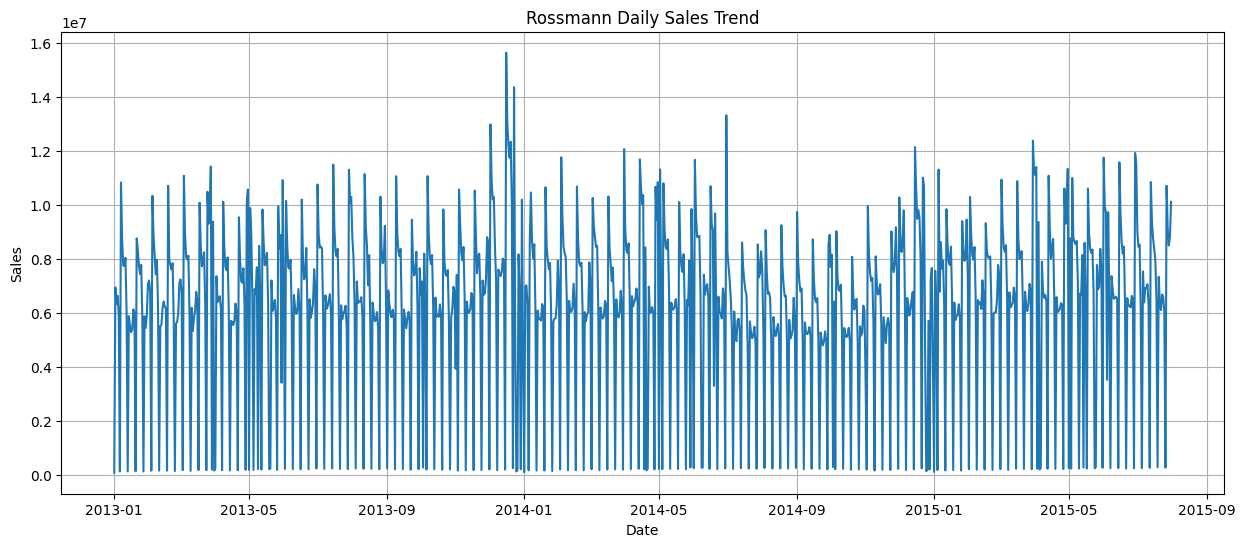

In [42]:
# ============================================================
# SECTION 4: VISUALIZE TIME SERIES
# ============================================================


plt.figure(figsize=(15,6))

plt.plot(
    daily_sales.index,
    daily_sales["Sales"]
)

plt.title(
    "Rossmann Daily Sales Trend"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Sales"
)

plt.grid()

plt.show()

In [43]:
# ============================================================
# SECTION 5: TRAIN TEST SPLIT
# ============================================================

# Last 90 days are kept as unseen data
# This simulates real future forecasting

test_days = 90


train_ts = daily_sales.iloc[:-test_days]

test_ts = daily_sales.iloc[-test_days:]


print(
    "Training Days:",
    len(train_ts)
)

print(
    "Testing Days:",
    len(test_ts)
)



Training Days: 852
Testing Days: 90


In [44]:
# ============================================================
# SECTION 6: EVALUATION FUNCTION
# ============================================================


def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )


    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )


    # MAPE can explode when actual sales are zero.
    # Therefore zero values are replaced by 1.

    mape = (
        np.abs(
            (y_true - y_pred) /
            np.where(
                y_true == 0,
                1,
                y_true
            )
        ).mean()
        * 100
    )


    return mae, rmse, mape



# Store all model results here

results = []


In [45]:
# ============================================================
# SECTION 7: NAIVE FORECAST
# ============================================================

# Assumption:
#
# Tomorrow's sales = Today's sales


naive_forecast = np.repeat(
    train_ts["Sales"].iloc[-1],
    len(test_ts)
)


mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    naive_forecast
)


results.append(
    [
        "Naive Forecast",
        mae,
        rmse,
        mape
    ]
)

In [46]:
# ============================================================
# SECTION 8: SEASONAL NAIVE FORECAST
# ============================================================

# Rossmann has weekly seasonality.
#
# Example:
# Next Monday sales are similar to previous Monday.


last_week = train_ts["Sales"].iloc[-7:].values


seasonal_naive_forecast = np.tile(
    last_week,
    int(np.ceil(len(test_ts)/7))
)[:len(test_ts)]



mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    seasonal_naive_forecast
)


results.append(
    [
        "Seasonal Naive",
        mae,
        rmse,
        mape
    ]
)



In [47]:
# ============================================================
# SECTION 9: MOVING AVERAGE
# ============================================================

# Forecast is based on average of previous 7 days


moving_average_value = (
    train_ts["Sales"]
    .rolling(window=7)
    .mean()
    .iloc[-1]
)


moving_average_forecast = np.repeat(
    moving_average_value,
    len(test_ts)
)


mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    moving_average_forecast
)


results.append(
    [
        "Moving Average",
        mae,
        rmse,
        mape
    ]
)

In [48]:
# ============================================================
# SECTION 10: WEIGHTED MOVING AVERAGE
# ============================================================

# Recent days get more importance

weights = np.array(
    [
        0.05,
        0.10,
        0.15,
        0.15,
        0.20,
        0.15,
        0.20
    ]
)


last_7_sales = (
    train_ts["Sales"]
    .iloc[-7:]
    .values
)


weighted_average = np.sum(
    last_7_sales * weights
)


weighted_forecast = np.repeat(
    weighted_average,
    len(test_ts)
)


mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    weighted_forecast
)


results.append(
    [
        "Weighted Moving Average",
        mae,
        rmse,
        mape
    ]
)


In [49]:
# ============================================================
# SECTION 11: SIMPLE EXPONENTIAL SMOOTHING
# ============================================================

# Captures level only

ses_model = SimpleExpSmoothing(
    train_ts["Sales"]
).fit()


ses_forecast = ses_model.forecast(
    len(test_ts)
)



mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    ses_forecast
)


results.append(
    [
        "SES",
        mae,
        rmse,
        mape
    ]
)

In [50]:
# ============================================================
# SECTION 12: HOLT LINEAR TREND MODEL
# ============================================================

# Captures:
# Level + Trend
# Does NOT capture seasonality


holt_model = Holt(
    train_ts["Sales"]
).fit()



holt_forecast = holt_model.forecast(
    len(test_ts)
)



mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    holt_forecast
)


results.append(
    [
        "Holt",
        mae,
        rmse,
        mape
    ]
)

In [51]:
# ============================================================
# SECTION 13: HOLT-WINTERS MODEL
# ============================================================

# Captures:
#
# 1. Level
# 2. Trend
# 3. Seasonality
#
# Rossmann has weekly seasonality,
# therefore seasonal_periods = 7


hw_model = ExponentialSmoothing(
    train_ts["Sales"],
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit()



hw_forecast = hw_model.forecast(
    len(test_ts)
)



mae, rmse, mape = evaluate_model(
    test_ts["Sales"],
    hw_forecast
)


results.append(
    [
        "Holt-Winters",
        mae,
        rmse,
        mape
    ]
)

In [52]:
# ============================================================
# SECTION 14: MODEL COMPARISON
# ============================================================


results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "MAPE"
    ]
)


results_df = results_df.sort_values(
    by="RMSE"
)


print(
    results_df
)

                     Model           MAE          RMSE        MAPE
6             Holt-Winters  1.250170e+06  1.789503e+06   88.835967
4                      SES  2.333334e+06  3.228629e+06  407.201088
2           Moving Average  2.306305e+06  3.264030e+06  438.614376
3  Weighted Moving Average  2.408865e+06  3.476268e+06  489.633318
0           Naive Forecast  2.687301e+06  3.851607e+06  543.015227
1           Seasonal Naive  2.911575e+06  4.072885e+06  119.212526
5                     Holt  5.190674e+06  6.321653e+06  712.319842


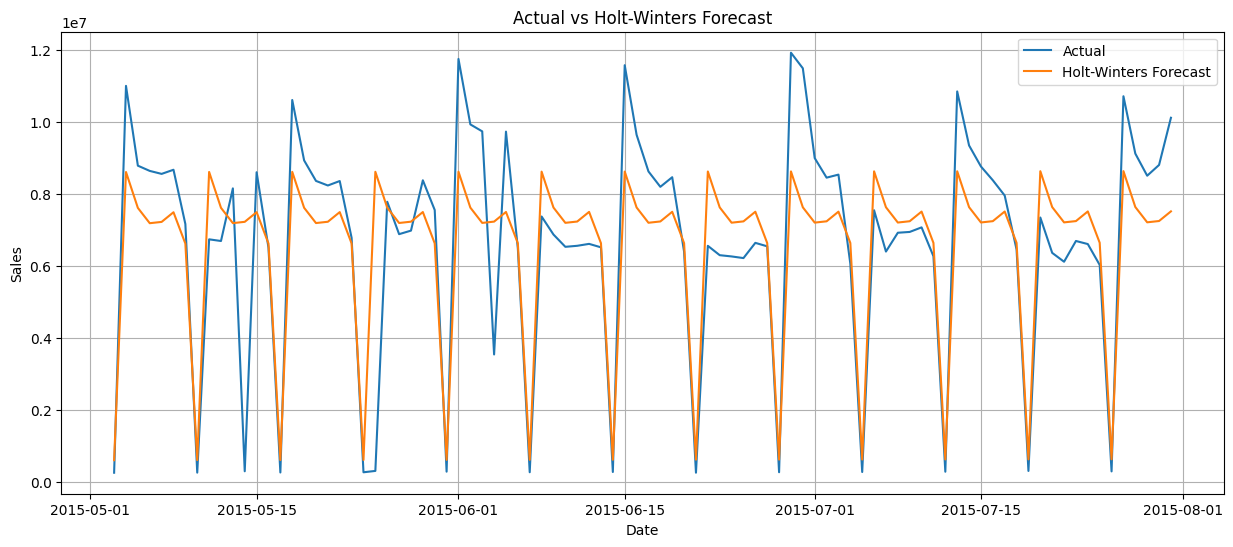

In [53]:
# ============================================================
# SECTION 15: BEST MODEL VISUALIZATION
# ============================================================


plt.figure(figsize=(15,6))


plt.plot(
    test_ts.index,
    test_ts["Sales"],
    label="Actual"
)


plt.plot(
    test_ts.index,
    hw_forecast,
    label="Holt-Winters Forecast"
)


plt.title(
    "Actual vs Holt-Winters Forecast"
)


plt.xlabel(
    "Date"
)


plt.ylabel(
    "Sales"
)


plt.legend()

plt.grid()

plt.show()

In [54]:
# ============================================================
# SECTION 16: PHASE 1 CONCLUSION
# ============================================================


best_model = results_df.iloc[0]["Model"]


print(
    "Best Phase 1 Model:",
    best_model
)

Best Phase 1 Model: Holt-Winters
